# Introdução às Redes Neurais e Deep Learning

## O Perceptron Multicamada - Continuação

### Derivadas da funções de ativação
* Função Linear
  $$f'(z)=1$$
* Função Sigmoide
  $$f(z)=\frac{1}{1+e^{-z}} \rightarrow  f'(z)=\frac{e^{-z}}{\left(1+e^{-z}\right)^2}=\frac{1}{1+e^{-z}}\frac{e^{-z}}{1+e^{-z}}=f(z)\left(1-\frac{e^{-z}}{1+e^{-z}}\right)=f(z)(1-f(z))$$
* Função Tangente Hiperbólica
  $$f(z)=\tanh z \rightarrow \left(\frac{\sinh z}{\cosh z}\right )^{'}=1-\left(\frac{\sinh z}{\cosh z}\right)^2=1-\tanh z^2=f(z)(1-f(z)^2)$$
<div>
<img src="Files\DER_F_ativ.png" width="500" height="700">   
</div>
* função Relu
  $$f'(z)=\begin{cases}0,&z\le 0\\1,&z>0\end{cases}$$

**Exercício**

Para a rede descrita na aula anterior, inicialmente com todos os pesos com valor unitário, *bias* nulos, , $X_1=1$  $X_2=0$, $y=1$ (porta XOR), Função MSE de perdas e sigmoide como ativação, determine:
* A saída $\hat{y}$;
* atualize os pesos e *bias* uma vez em uma iteração do método dos gradientes descendentes estocástico. 

### Implementação de uma Rede neural didática

In [1]:
import numpy as np

#### Função de ativação Sigmoide e Função de perdas MSE

In [2]:
# função sigmoide
def activation_function(x):
 return 1 / (1 + np.exp(-x))

def deriv_activ_function(x):
  fx = activation_function(x)
  return fx * (1 - fx)

# MSE
def mse_loss(y_true, y_hat):
  return ((y_true - y_hat) ** 2).mean()

def der_mse_loss(y_true,y_hat):
  return -2 * (y_true - y_hat)

#### Rede Neural

In [3]:
class NeuralNetwork:
  np.random.seed(0)
  def __init__(self):
    # Weigths e bias na primeira camada
    self.w1 = np.random.normal()
    self.w2 = np.random.normal()
    self.w3 = np.random.normal()
    self.w4 = np.random.normal()
    self.w5 = np.random.normal()
    self.w6 = np.random.normal()      
    self.b1 = np.random.normal()
    self.b2 = np.random.normal()
    self.b3 = np.random.normal()
      
    # Weigths e bias na segunda camada
    self.w7 = np.random.normal()
    self.w8 = np.random.normal()
    self.w9 = np.random.normal()
    self.b4 = np.random.normal()

  # Feedforward
  def feedforward(self, x):
    # Na camada intermediária
    h1 = activation_function(self.w1 * x[0] + self.w2 * x[1] + self.b1)
    h2 = activation_function(self.w3 * x[0] + self.w4 * x[1] + self.b2)
    h3 = activation_function(self.w5 * x[0] + self.w6 * x[1] + self.b3)
      
    # na camada de saída
    y_hat = activation_function(self.w7 * h1 + self.w8 * h2 + self.w9*h3+self.b4)
      
    return y_hat

  #Treino com retropropagação
  def train(self, data, y_trues,loss):
    
    eta = 0.2
    epochs = 2000 # número de ciclos sobre o conjunto de dados
    iloss=0

    for epoch in range(epochs):
      for x, y_true in zip(data, y_trues):
          
        # Feedforward 
        z_1 = self.w1 * x[0] + self.w2 * x[1] + self.b1
        h1 = activation_function(z_1)
        z_2 = self.w3 * x[0] + self.w4 * x[1] + self.b2
        h2 = activation_function(z_2)
        z_3 = self.w5 * x[0] + self.w6 * x[1] + self.b3
        h3 = activation_function(z_3)

        z_y = self.w7 * h1 + self.w8 * h2 + self.w9*h3 + self.b4
        y_hat = activation_function(z_y)

        # Retropropagação
        dL_dY = der_mse_loss(y_true,y_hat)

        # Neurônio 1 na camada de saída
        dY_dW7 = h1 * deriv_activ_function(z_y)
        dY_dW8 = h2 * deriv_activ_function(z_y)
        dY_dW9 = h3 * deriv_activ_function(z_y)
        dY_db4 = deriv_activ_function(z_y)

        dY_dh1 = self.w7 * deriv_activ_function(z_y)
        dY_dh2 = self.w8 * deriv_activ_function(z_y)
        dY_dh3 = self.w9 * deriv_activ_function(z_y)

        # Camada 1
        # Neurônio 1
        dh1_dW1 = x[0] * deriv_activ_function(z_1)
        dh1_dW2 = x[1] * deriv_activ_function(z_1)
        dh1_db1 = deriv_activ_function(z_1)

        # Neurônio 2
        dh2_dW3 = x[0] * deriv_activ_function(z_2)
        dh2_dW4 = x[1] * deriv_activ_function(z_2)
        dh2_db2 = deriv_activ_function(z_2)

        # Neurônio 3
        dh3_dW5 = x[0] * deriv_activ_function(z_3)
        dh3_dW6 = x[1] * deriv_activ_function(z_3)
        dh3_db3 = deriv_activ_function(z_3)

        # Atualização dos pesos e bias
        # Neurônio 1
        self.w1 -= eta * dL_dY * dY_dh1 * dh1_dW1
        self.w2 -= eta * dL_dY * dY_dh1 * dh1_dW2
        self.b1 -= eta * dL_dY * dY_dh1 * dh1_db1

        # Neurônio 2
        self.w3 -= eta * dL_dY * dY_dh2 * dh2_dW3
        self.w4 -= eta * dL_dY * dY_dh2 * dh2_dW4
        self.b2 -= eta * dL_dY * dY_dh2 * dh2_db2

        # Neurônio 3
        self.w5 -= eta * dL_dY * dY_dh3 * dh3_dW5
        self.w6 -= eta * dL_dY * dY_dh3 * dh3_dW6
        self.b3 -= eta * dL_dY * dY_dh3 * dh3_db3

        # Neurônio da camada de saída
        self.w7 -= eta * dL_dY* dY_dW7
        self.w8 -= eta * dL_dY * dY_dW8
        self.w9 -= eta * dL_dY * dY_dW9
        self.b4 -= eta * dL_dY * dY_db4

      # --- Calculate total loss at the end of each epoch
      if epoch % 10 == 0:
        y_preds = np.apply_along_axis(self.feedforward, 1, data)
        loss[iloss] = mse_loss(y_trues, y_preds) 
        if epoch % 100 == 0:
            print("Epoch %d loss: %.3f" % (epoch, loss[iloss]))              
        iloss=iloss+1
    
    print('\n'+'y_preds=',np.round(y_preds))
        

#### Teste com a porta XOR

In [4]:
# Data
X = np.array([
  [0, 0], 
  [0,1],  
  [1,0],   
  [1,1], 
])
y = np.array([
  0, 
  1, 
  1,
  0, 
])

#### Treinando a rede

In [5]:
loss=np.zeros(200)
network = NeuralNetwork()
network.train(X, y,loss)

Epoch 0 loss: 0.388
Epoch 100 loss: 0.239
Epoch 200 loss: 0.209
Epoch 300 loss: 0.142
Epoch 400 loss: 0.070
Epoch 500 loss: 0.035
Epoch 600 loss: 0.021
Epoch 700 loss: 0.015
Epoch 800 loss: 0.011
Epoch 900 loss: 0.008
Epoch 1000 loss: 0.007
Epoch 1100 loss: 0.006
Epoch 1200 loss: 0.005
Epoch 1300 loss: 0.004
Epoch 1400 loss: 0.004
Epoch 1500 loss: 0.004
Epoch 1600 loss: 0.003
Epoch 1700 loss: 0.003
Epoch 1800 loss: 0.003
Epoch 1900 loss: 0.002

y_preds= [0. 1. 1. 0.]


#### Gráfico Loss X Épocas

Text(0, 0.5, 'Loss')

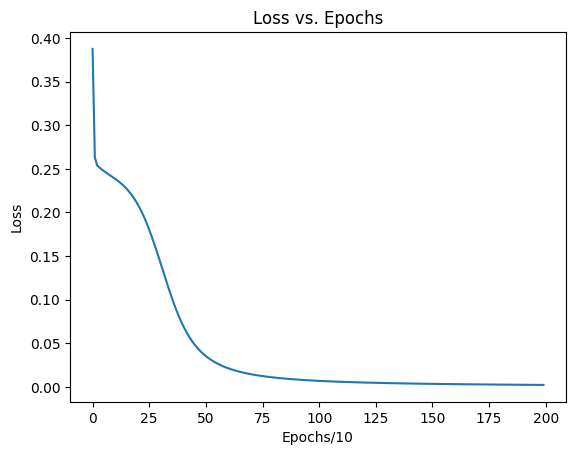

In [6]:
import matplotlib.pyplot as plt
plt.title('Loss vs. Epochs')
plt.plot(loss)
plt.xlabel('Epochs/10')
plt.ylabel('Loss')